# 02. Factor Research Workbench
**Objective:** rigorous prototyping, validation, and decay analysis of alpha factors.

### Institutional Workflow:
1. **Factor Construction:** Vectorized definition using pandas/numpy.
2. **IC Analysis:** Information Coefficient (Spearman) over time, t-stats, and ICIR.
3. **Quantile Analysis:** Monotonicity of returns across quintiles/deciles.
4. **Alpha Decay:** Signal persistence analysis to determine turnover requirements.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path('../').resolve()
sys.path.append(str(PROJECT_ROOT))

from config.settings import config
from quant_alpha.utils import load_parquet
from quant_alpha.research.factor_analysis import FactorAnalyzer
from quant_alpha.research.alpha_decay import AlphaDecayAnalyzer

%matplotlib inline

## 1. Load Data & Define Factor
Example: **Volatility-Adjusted Momentum** (Return / StdDev)

In [2]:
df = load_parquet(config.CACHE_DIR / 'master_data_with_factors.parquet')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

# --- Institutional Data Prep ---
if 'raw_ret_5d' not in df.columns:
    print("⚠️ 'raw_ret_5d' missing. Calculating from Open prices (T+1 to T+6)...")
    df['next_open'] = df.groupby('ticker', observed=False)['open'].shift(-1)
    df['future_open'] = df.groupby('ticker', observed=False)['open'].shift(-6)
    df['raw_ret_5d'] = (df['future_open'] / df['next_open']) - 1

# --- PROTOTYPE FACTOR HERE ---
# Example: Volatility-Adjusted Momentum (20d)
window = 20
df['mom_20'] = df.groupby('ticker', observed=False)['close'].pct_change(window)
df['vol_20'] = df.groupby('ticker', observed=False)['close'].transform(lambda x: x.pct_change().rolling(window).std())

# Handle division by zero / infs
df['alpha_signal'] = df['mom_20'] / (df['vol_20'] + 1e-8)
df['alpha_signal'] = df['alpha_signal'].replace([np.inf, -np.inf], np.nan)

# Clean up for analysis
analysis_df = df.dropna(subset=['alpha_signal', 'raw_ret_5d']).copy()
print(f"Factor defined. Analysis set: {len(analysis_df):,} rows.")

Factor defined. Analysis set: 625,205 rows.


## 2. Information Coefficient (IC) Analysis

--- IC Summary ---
{'Mean IC': 0.0038325117114869313, 'IC Std': 0.16962039625803166, 'ICIR (IC/Std)': 0.02259463953649064, 'Hit Ratio (>0)': 0.5283911671924291, 't-stat': 0.8045722397485783, 'N': 1268}

💡 NOTE: Positive IC indicates Momentum (High Factor -> High Return).


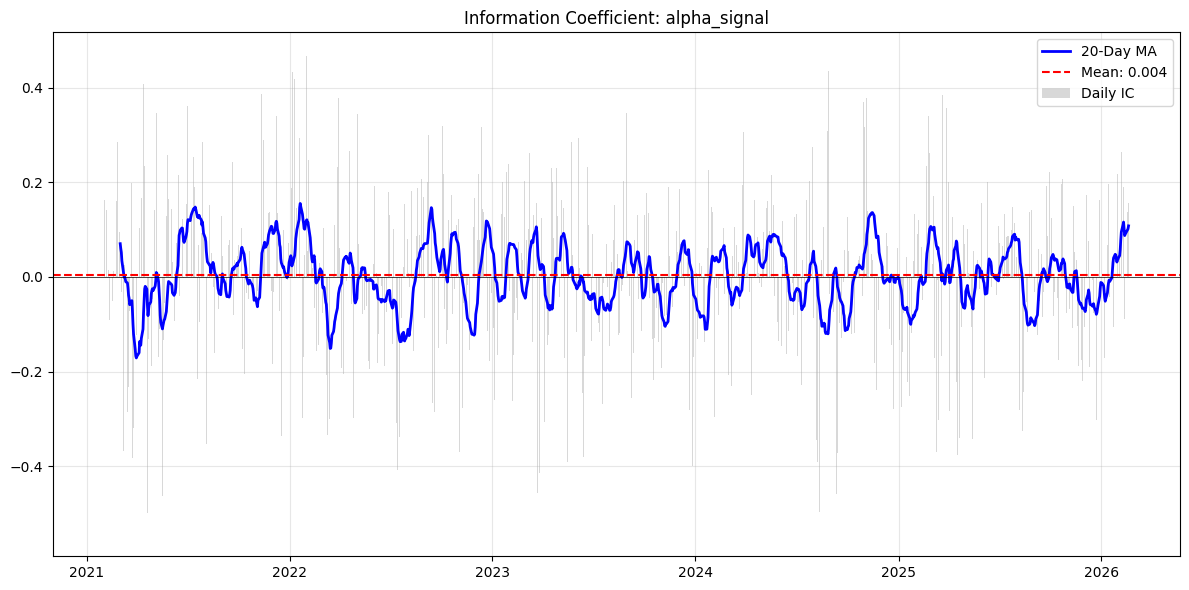

In [3]:
analyzer = FactorAnalyzer(analysis_df, factor_col='alpha_signal', target_col='raw_ret_5d')

print("--- IC Summary ---")
summary = analyzer.get_ic_summary()
print(summary)

if summary['Mean IC'] < 0:
    print("\n💡 NOTE: Negative IC indicates Mean Reversion (High Factor -> Low Return).")
elif summary['Mean IC'] > 0:
    print("\n💡 NOTE: Positive IC indicates Momentum (High Factor -> High Return).")

analyzer.plot_ic_ts(window=20)

## 3. Quantile Analysis
Does the top quintile consistently outperform the bottom?

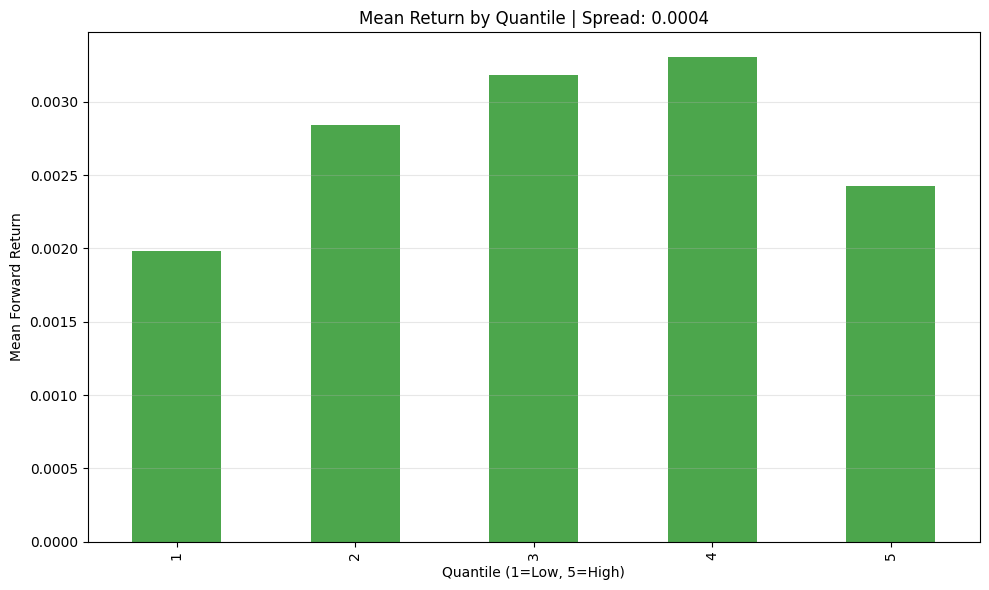

In [4]:
analyzer.plot_quantile_returns(quantiles=5)

## 4. Alpha Decay Analysis
How long does the signal remain predictive?

E:\coding\quant_alpha_research\quant_alpha\research\alpha_decay.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = valid.groupby('date').apply(
E:\coding\quant_alpha_research\quant_alpha\research\alpha_decay.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = valid.groupby('date').apply(
E:\coding\quant_alpha_research\quant_alpha\research\alpha_decay.py:112: FutureWarning: DataFrameGroupBy.

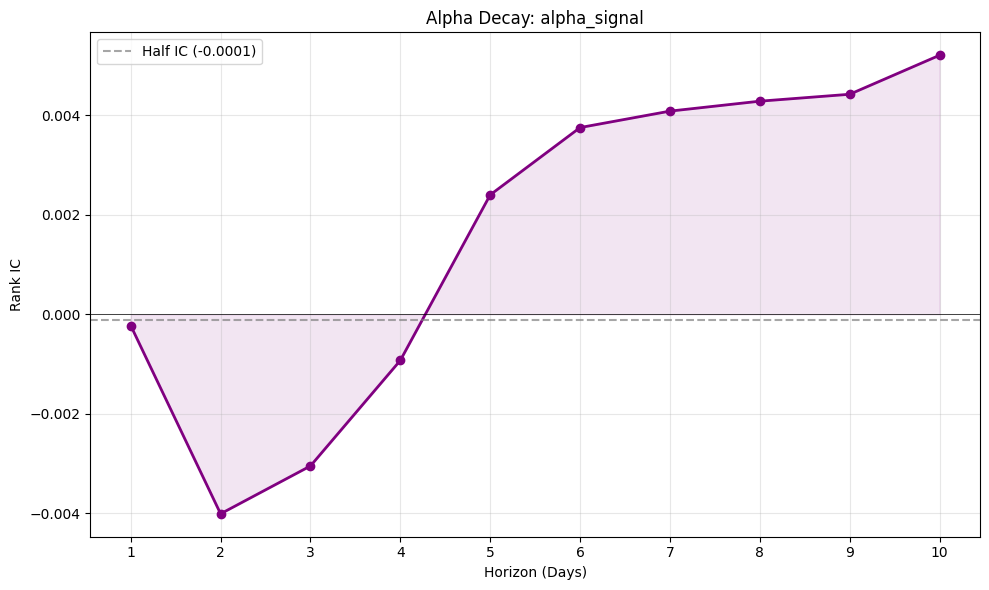

In [5]:
decay = AlphaDecayAnalyzer(analysis_df, factor_col='alpha_signal')
decay.calculate_decay(max_horizon=10)
decay.plot_decay()